In [ ]:
# --- repo bootstrap -------------------------------------------------------------
# All paths in this notebook are relative to the repository root, so switch there
# first (the notebook can then be launched from any directory) and put src/ on the
# import path for `epochalypse_fitting`, `epochalypse_figures`, `run_*_periodograms`.
import os, sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "epochalypse_fitting.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)


In [1]:
import pandas as pd
import os
import hashlib
import numpy as np
import astropy.units as u
from astropy.constants import M_jup, M_earth
import astropy.units as u
import matplotlib.pyplot as plt

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)




In [2]:
sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')
sample_sources_w_mass_radius

/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_50852/2743170194.py:1: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')


,gaia_source_id,source_id_dr2,hip_id,ra,dec,ra_error,dec_error,parallax,radial_velocity,pmra_hip,...,predicted_class_msms,q_binary_msms,ra_msms,radial_velocity_msms,radial_velocity_error_msms,astrometric_chi2_al_dr3,parallax_error,abs_G,mass_interp,radius_interp
0,5479559378348931200,5479559378348931200,NaN,104.451569,-60.372920,0.017413,0.017271,9.163278,31.439222,NaN,...,1.0,0.367839,104.451569,31.439222,5.467342,352.30774,0.018659,9.517337,0.416070,0.431044
1,5481069145252396928,5481069145252396928,NaN,94.501858,-61.931762,0.019870,0.017888,10.807500,72.872055,NaN,...,0.0,0.100000,94.501858,72.872055,4.053698,337.33606,0.018703,10.095283,0.364478,0.357631
2,5481478983915584256,5481478983915584256,NaN,95.883588,-61.539116,0.099535,0.093117,12.664252,13.964805,NaN,...,1.0,0.867628,95.883588,13.964805,1.014977,29628.98800,0.094480,8.248793,0.560486,0.574047
3,5481618557469377408,5481618557469377408,NaN,97.669544,-60.554270,0.015607,0.015902,5.860141,26.489969,NaN,...,1.0,0.614483,97.669544,26.489970,3.861051,324.32617,0.015685,8.568322,0.526492,0.529479
4,5481843025342799104,5481843025342799104,NaN,96.483493,-60.057018,0.017501,0.018088,74.421765,32.207623,NaN,...,1.0,0.480041,96.483493,32.207623,0.323626,2246.94120,0.018152,10.391425,0.328363,0.335601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16374,6879764552737781888,6879764552737781888,99572.0,303.108674,-12.618367,0.034322,0.019407,35.418534,27.201628,192.187363,...,NaN,NaN,NaN,NaN,NaN,1666.47230,0.035101,3.468151,1.274493,1.393903
16375,6881507171289815808,6881507171289815808,NaN,314.966530,-19.270865,0.494852,0.328530,5.787716,-22.518469,NaN,...,NaN,NaN,NaN,NaN,NaN,166320.10000,0.587363,8.769341,0.505333,0.506732
16376,6891134705556330880,6891134705556330880,106147.0,322.516126,-12.511222,0.020525,0.016549,56.426457,-84.689545,1017.014771,...,NaN,NaN,NaN,NaN,NaN,825.46310,0.023555,7.297645,0.664760,0.649312
16377,6905063765533078272,6905063765535544832,NaN,308.194628,-8.897616,0.062833,0.047892,10.033755,-32.714832,NaN,...,NaN,NaN,NaN,NaN,NaN,1587.22190,0.069177,5.890081,0.813505,0.778453


In [3]:
def near_first_order_resonance(a1, a2, j, tol=0.05):
    """
    Flag proximity to (j+1):j resonance.

    Parameters
    ----------
    tol : fractional tolerance (e.g. 0.01–0.05)

    Notes
    -----
    This is a selection criterion, not a dynamical stability condition. 
    
    It estimates based on an integer j, whether you are within decimal tol 
    of j+1/j first-order resonance.

    """
    P_ratio = (a2 / a1) ** 1.5
    target = (j + 1) / j
    return abs(P_ratio / target - 1) < tol

def classify_with_resonance(mu1, mu2, a1, a2, e1, e2):
    # 1. Orbit crossing → always unstable
    if a1*(1+e1) >= a2*(1-e2):
        return "unstable"

    # 2. Hill spacing
    RH = ((mu1+mu2)/3)**(1/3)*(a1+a2)/2
    delta = (a2-a1)/RH

    # 3. Check near resonance (2:1 and 3:2 only for now)
    near_res = (
        near_first_order_resonance(a1, a2, j=1) or
        near_first_order_resonance(a1, a2, j=2)
    )

    if delta < 2*np.sqrt(3):
        if near_res:
            return "resonant_stable_possible"
        else:
            return "likely_unstable"

    return "stable"

In [4]:

M_JUP_IN_MSUN = 9.5458e-4
PLANET_MASTER_SEED = 42

# Semi-major axis prior: log-uniform between these bounds [AU]. Lowering A_MIN_AU pushes injected
# periods down as P = sqrt(a^3 / M): at 0.1 AU that is 5 d for the lightest star in the catalog
# (0.078 Msun), 16 d at the median 0.55 Msun. 
A_MIN_AU, A_MAX_AU = 0.1, 100.0


def stable_population_seed(master_seed, population_name):
    """Return a stable uint32 seed independent of Python's hash randomization."""
    payload = f"{int(master_seed)}:{population_name}".encode("utf-8")
    return int.from_bytes(hashlib.blake2s(payload, digest_size=4).digest(), "little")

def semimajor_axis_to_period(a_au, mtot_msun):
    """Kepler's third law: P [yr] from a [AU] and total system mass
    M_star + M_p [Msun]. The companion mass is not negligible for the
    highest-mass companions in the prior (e.g. an 80 M_Jup brown dwarf is
    ~15% of a 0.5 Msun star), so it is retained here."""
    return np.sqrt(a_au**3 / mtot_msun)

def gen_orbits_csv(star_catalog_path, output_dir, output_file, filter_snr=False, n_planets=1,  max_retries=1000, seed=42):
    '''
    Generates a CSV with 1 or 2 mock planets for real Gaia stars.
    Stability criterion for 2 planet systems must be met.

    Parameters:
    star_catalog_path : str
        Path to Gaia star catalog file.
    output_dir : str
        Directory for the output CSV. Created if it doesn't exist.
    output_file : str
        Filename for the output CSV.
    filter_snr : bool, optional
        If True, apply SNR-based rejection sampling. Default is False.
    n_planets : int, optional
        1 or 2. Default is 1.
    batch_size : int, optional
        Proposal pool size per iteration (only matters when rejection
        sampling is active). Default is 50000.
    Returns:
    csv_data : pandas.DataFrame
    '''
    M_mars_Mjup = (0.107 * M_earth).to(u.M_jup).value
    T_BASELINE = 5.5
    M_jup_per_Msun = M_jup.to(u.M_sun).value
    rng = np.random.default_rng(seed)
    os.makedirs(output_dir, exist_ok=True)

    catalog = pd.read_csv(
        star_catalog_path,
        dtype={"gaia_source_id": str, "source_id_dr2": str},
        low_memory=False,
    )

    # Exclude sources lacking a per-CCD AL noise calibration (sig_AL is NaN):
    # a handful of high-RUWE binaries with no usable noise model. Dropped here
    # so every population shares one clean parent sample.
    n_before = len(catalog)
    catalog = catalog[np.isfinite(catalog["sig_AL"].to_numpy(dtype=float))].reset_index(drop=True)
    if len(catalog) < n_before:
        print(f"  Dropped {n_before - len(catalog)} stars with missing sig_AL (no noise model)")

    n_stars = len(catalog)
    gaia_source_ids = catalog['gaia_source_id'].values
    source_id_dr2s = catalog['source_id_dr2'].values
    mstar_arr = catalog['mass_interp'].values

    # DR4 detectability selection. The single-transit S/N is accumulated over
    # the N_DR4 field-of-view transits each star receives (S/N grows as
    # sqrt(N)), and we keep planets whose period-suppressed *total* S/N clears
    # SNR_TOTAL_MIN_DR4:
    #   SNR_total = sqrt(N_DR4) * SNR_1 / (1 + (a / a_crit)**3)
    # This replaces the earlier per-single-datum cut of 1.5: folding in how many
    # times each star is observed, a single-transit S/N of ~1.5 over a typical
    # ~90 DR4 transits corresponds to a total S/N well above the new cut of 10.
    SNR_TOTAL_MIN_DR4 = 10.0
    # Rather than a hard period cut, suppress the S/N smoothly as the orbit
    # exceeds the observing baseline (G23H-style proxy detectability metric).
    # a_crit is the semi-major axis whose period equals T_BASELINE, so the
    # suppression turns on once P exceeds the 5.5 yr DR4 baseline.
    parallax_arr = catalog['parallax'].to_numpy(dtype=float)
    n_good_arr = catalog['astrometric_n_good_obs_al_dr3'].to_numpy(dtype=float)
    n_fov_arr = catalog['astrometric_matched_transits_dr3'].to_numpy(dtype=float)

    # Number of DR4 FoV transits per star, taken directly from the per-star
    # scan law in sample_scanlaw_dr4.arrow (one row per FoV transit). This is
    # the N in the sqrt(N) term above -- exact per-star transit counts rather
    # than a sky-position estimate. (The DR3 matched-transit column is the wrong
    # data release, and n_good_obs counts CCD measurements, ~9 per transit.)
    import pyarrow as pa
    import pyarrow.ipc as ipc
    SCANLAW_DR4_PATH = "./data/g23h_epochalypse_stars/sample_scanlaw_dr4.arrow"
    with pa.memory_map(SCANLAW_DR4_PATH, "r") as _sl:
        _scanlaw_ids = ipc.open_file(_sl).read_all().column("gaia_source_id").to_numpy()
    _uid, _ucount = np.unique(_scanlaw_ids, return_counts=True)
    _n_transits_by_id = dict(zip(_uid.astype(str), _ucount.astype(float)))
    n_dr4_arr = np.array([_n_transits_by_id.get(str(sid), np.nan)
                          for sid in gaia_source_ids], dtype=float)
    sigma_al_arr = catalog['sig_AL'].to_numpy(dtype=float)
    sigma_calib_arr = catalog['sig_cal'].to_numpy(dtype=float)
    params_solved_arr = catalog['astrometric_params_solved_dr3'].to_numpy()

    def _single_datum_sigma(i):
        n_good = n_good_arr[i]
        n_fov = n_fov_arr[i]
        n_dof = 5 if params_solved_arr[i] == 31 else 6
        if not np.isfinite(n_good) or not np.isfinite(n_fov) or n_fov <= 0 or n_good <= n_dof:
            return np.nan
        n_al_ave = n_good / n_fov
        mu_ueva_single = (
            n_al_ave / (n_good - n_dof)
            * ((n_fov - n_dof) * sigma_calib_arr[i]**2 + n_fov * sigma_al_arr[i]**2)
        )
        return np.sqrt(mu_ueva_single / n_al_ave)

    sigma_single_arr = np.array([_single_datum_sigma(i) for i in range(n_stars)])

    def _draw_one_planet(mstar, parallax_mas, sigma_single_mas, n_dr4,
                         batch=4096, max_draws=8_000_000):
        """Draw a planet from the mass/sma prior. When filter_snr is set, keep
        only planets whose period-suppressed *total* detectability clears
        SNR_TOTAL_MIN_DR4, accumulating the single-transit S/N over the star's
        N_DR4 field-of-view transits:
            SNR_total = sqrt(n_dr4) * (alpha / sigma_single) / (1 + (a / a_crit)**3)
        with a_crit = (T_BASELINE**2 * mstar)**(1/3). Returns
        (sma, mass, alpha, snr_single, snr_eff, snr_total), or None if no
        acceptable planet is found within max_draws (i.e. this star hosts no
        detectable planet)."""
        if filter_snr and (not np.isfinite(sigma_single_mas) or sigma_single_mas <= 0
                           or not np.isfinite(n_dr4) or n_dr4 <= 0):
            return None
        a_crit = (T_BASELINE**2 * mstar)**(1.0 / 3.0)
        drawn = 0
        while drawn < max_draws:
            sma = 10**rng.uniform(np.log10(A_MIN_AU), np.log10(A_MAX_AU), size=batch)
            mass = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80), size=batch)
            mass_msun = mass * M_JUP_IN_MSUN
            alpha_mas = mass_msun / (mstar + mass_msun) * sma * parallax_mas
            snr_single = alpha_mas / sigma_single_mas
            snr_eff = snr_single / (1.0 + (sma / a_crit)**3)
            snr_total = np.sqrt(n_dr4) * snr_eff
            accept = np.ones(batch, dtype=bool)
            if filter_snr:
                accept &= np.isfinite(snr_total) & (snr_total >= SNR_TOTAL_MIN_DR4)
            hits = np.where(accept)[0]
            if hits.size:
                idx = hits[0]
                return (sma[idx], mass[idx], alpha_mas[idx],
                        snr_single[idx], snr_eff[idx], snr_total[idx])
            drawn += batch
        return None

    def _draw_angles(rng):
        ecc = rng.uniform(0, 0.99)
        inc = np.degrees(np.arccos(rng.uniform(-1, 1)))
        Omega = rng.uniform(0, 360)
        omega = rng.uniform(0, 360)
        M_anom = rng.uniform(0, 360)
        return ecc, inc, Omega, omega, M_anom

    rows = []
    n_failed = 0
    n_missing_sigma = 0
    n_no_detectable = 0

    for i in range(n_stars):
        gaia_sid = gaia_source_ids[i]
        dr2_sid = source_id_dr2s[i]
        mstar = mstar_arr[i]

        parallax_mas = parallax_arr[i]
        sigma_single_mas = sigma_single_arr[i]
        n_dr4 = n_dr4_arr[i]

        # Lammers & Winn SNR filtering needs a valid per-star single-datum
        # noise estimate. A few stars lack one (e.g. missing sig_AL -> NaN
        # sigma), so drop them from the filtered population rather than
        # aborting the whole run.
        if filter_snr and not (np.isfinite(sigma_single_mas) and sigma_single_mas > 0
                               and np.isfinite(n_dr4) and n_dr4 > 0):
            n_missing_sigma += 1
            continue
        if n_planets == 1:
            drawn = _draw_one_planet(mstar, parallax_mas, sigma_single_mas, n_dr4)
            if drawn is None:
                n_no_detectable += 1
                continue
            sma, mass_pl, alpha_mas, snr_single, snr_eff, snr_total = drawn
            ecc, inc, Omega, omega, M_anom = _draw_angles(rng)
            rows.append({
                'gaia_source_id': gaia_sid,
                'source_id_dr2': dr2_sid,
                'mass_st': mstar,
                'sma': sma, 
                'ecc': ecc, 
                'mass_pl': mass_pl,
                'inc': inc, 
                'Omega': Omega, 
                'omega': omega, 
                'M_anom': M_anom,
                'period': semimajor_axis_to_period(sma, mstar + mass_pl * M_JUP_IN_MSUN),
                'alpha_mas': alpha_mas,
                'sigma_single_mas': sigma_single_mas,
                'snr_single': snr_single,
                'snr_eff': snr_eff,
                'snr_total': snr_total,
                'n_transits_dr4': n_dr4,
            })
        else:  # n_planets == 2
            found = False
            no_detectable = False
            for attempt in range(max_retries):
                draw1 = _draw_one_planet(mstar, parallax_mas, sigma_single_mas, n_dr4)
                draw2 = _draw_one_planet(mstar, parallax_mas, sigma_single_mas, n_dr4)
                if draw1 is None or draw2 is None:
                    no_detectable = True
                    break
                sma1, mass1, alpha1, snr1, snr_eff1, snr_tot1 = draw1
                sma2, mass2, alpha2, snr2, snr_eff2, snr_tot2 = draw2
                ecc1, inc1, Om1, om1, Ma1 = _draw_angles(rng)
                ecc2, inc2, Om2, om2, Ma2 = _draw_angles(rng)
                coplanar = bool(rng.integers(2))
                if coplanar:
                    inc2 = inc1
                    Om2 = Om1

                # enforce sma1 < sma2 so closer in
                if sma1 > sma2:
                    sma1, sma2 = sma2, sma1
                    mass1, mass2 = mass2, mass1
                    alpha1, alpha2 = alpha2, alpha1
                    snr1, snr2 = snr2, snr1
                    snr_eff1, snr_eff2 = snr_eff2, snr_eff1
                    snr_tot1, snr_tot2 = snr_tot2, snr_tot1
                    ecc1, ecc2 = ecc2, ecc1
                    inc1, inc2 = inc2, inc1
                    Om1, Om2 = Om2, Om1
                    om1, om2 = om2, om1
                    Ma1, Ma2 = Ma2, Ma1

                mu1 = mass1 * M_jup_per_Msun / mstar
                mu2 = mass2 * M_jup_per_Msun / mstar
                label = classify_with_resonance(mu1, mu2, sma1, sma2, ecc1, ecc2)
                if label not in ("unstable", "likely_unstable"):
                    found = True
                    break

            if no_detectable:
                n_no_detectable += 1
                continue  # star hosts no detectable planet (period-suppressed S/N)
            if not found:
                n_failed += 1
                continue  # skip this star

            P1 = semimajor_axis_to_period(sma1, mstar + mass1 * M_JUP_IN_MSUN)
            P2 = semimajor_axis_to_period(sma2, mstar + mass2 * M_JUP_IN_MSUN)
            rows.append({
                'gaia_source_id': gaia_sid,
                'source_id_dr2': dr2_sid,
                'mass_st': mstar,
                'sma_1': sma1, 
                'ecc_1': ecc1, 
                'mass_pl_1': mass1,
                'inc_1': inc1, 
                'Omega_1': Om1, 
                'omega_1': om1, 
                'M_anom_1': Ma1,
                'sma_2': sma2, 
                'ecc_2': ecc2, 
                'mass_pl_2': mass2,
                'inc_2': inc2, 
                'Omega_2': Om2, 
                'omega_2': om2, 
                'M_anom_2': Ma2,
                'period_1': P1, 
                'period_2': P2,
                'alpha_1_mas': alpha1,
                'alpha_2_mas': alpha2,
                'sigma_single_mas': sigma_single_mas,
                'snr_single_1': snr1,
                'snr_single_2': snr2,
                'snr_eff_1': snr_eff1,
                'snr_eff_2': snr_eff2,
                'snr_total_1': snr_tot1,
                'snr_total_2': snr_tot2,
                'n_transits_dr4': n_dr4,
                'P_ratio': P2 / P1,
                'near_2_1': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=1)[0],
                'near_3_2': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=2)[0], 'coplanar': coplanar,
            })

        if (i + 1) % 500 == 0 or i == n_stars - 1:
            print(f"  processed {i+1} / {n_stars} stars")

    if n_failed:
        print(f"  WARNING: {n_failed} stars skipped (stability not met in {max_retries} attempts)")
    if n_missing_sigma:
        print(f"  WARNING: {n_missing_sigma} stars skipped (no valid single-datum sigma or DR4 scan law for SNR filter)")
    if n_no_detectable:
        print(f"  WARNING: {n_no_detectable} stars skipped (no companion clears period-suppressed total S/N >= {SNR_TOTAL_MIN_DR4:g})")

    csv_data = pd.DataFrame(rows)
    csv_data["generation_seed"] = int(seed)
    if n_planets == 2:
        csv_data['near_resonance'] = csv_data['near_2_1'] | csv_data['near_3_2']

        # --- stability / resonance summary (numbers for the write-up) ---
        n_sys = len(csv_data)
        n_res = int(csv_data['near_resonance'].sum())
        n_21 = int(csv_data['near_2_1'].sum())
        n_32 = int(csv_data['near_3_2'].sum())
        frac_res = (n_res / n_sys) if n_sys else 0.0
        print(
            f"  [{output_file}] two-companion stability/resonance summary:\n"
            f"    {n_sys} systems retained | near first-order MMR: "
            f"{n_res} ({frac_res:.1%}) [{n_21} near 2:1, {n_32} near 3:2]\n"
            f"    stars with no stable pair in {max_retries} attempts: {n_failed}"
        )

    output_fpath = os.path.join(output_dir, output_file)
    print(f"Writing {len(csv_data)} systems to {output_fpath}")
    csv_data.to_csv(output_fpath, index=False)
    return csv_data

def plot_pop_diagnostics(
    ag_path,
    snr_path,
    output_path="pop_diagnostics.png",
    n_planets=2,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # ---- publication-quality typography ----
    plt.rcParams.update({
        "axes.titlesize":  40,   # per-panel titles
        "axes.labelsize":  40,   # x and y axis labels
        "xtick.labelsize": 34,   # tick numbers
        "ytick.labelsize": 34,
        "legend.fontsize": 36,
        "axes.linewidth":  1.2,
    })

    ag = pd.read_csv(ag_path)
    snr = pd.read_csv(snr_path)

    AGNOSTIC_COLOR = "#050CDB"
    SNR_COLOR = "#DC144D"

    def overlay_hist(ax, ag_values, snr_values, bins=60):
        """Overlay densities using shared bin edges and fixed colors."""
        ag_values = np.asarray(ag_values)
        snr_values = np.asarray(snr_values)
        finite = np.concatenate([
            ag_values[np.isfinite(ag_values)],
            snr_values[np.isfinite(snr_values)],
        ])
        edges = np.histogram_bin_edges(finite, bins=bins)
        ax.hist(
            ag_values, bins=edges, density=True, histtype="stepfilled",
            color=AGNOSTIC_COLOR, edgecolor=AGNOSTIC_COLOR, linewidth=1.3,
            alpha=0.25,
        )
        ax.hist(
            snr_values, bins=edges, density=True, histtype="stepfilled",
            color=SNR_COLOR, edgecolor=SNR_COLOR, linewidth=1.3,
            alpha=0.25,
        )

    def style_axes(axes):
        for ax in np.asarray(axes).flat:
            ax.grid(axis="y", alpha=0.18, linewidth=0.7)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(width=1.1, length=5)
            ax.margins(x=0.02)

    def hline_label(ax, y, text, x=0.5, color="k"):
        """Label a horizontal reference line with bare text sitting on it.
        x is in axes fraction (0-1); y is in data coordinates."""
        ax.text(x, y, text, transform=ax.get_yaxis_transform(),
                ha="center", va="bottom", fontsize=17, color=color)

    def vline_label(ax, x, text, color="0.25"):
        """Label a vertical reference line with bare text running up the line."""
        ax.annotate(text, xy=(x-.05, 0.04), xycoords=("data", "axes fraction"),
                    xytext=(6, 0), textcoords="offset points",
                    rotation=90, rotation_mode="anchor",
                    ha="left", va="bottom", fontsize=24, color=color)

    # Proxy handles for the one shared population legend.
    pop_handles = [
        Patch(facecolor=AGNOSTIC_COLOR, edgecolor=AGNOSTIC_COLOR,
              alpha=0.40, linewidth=1.3, label=rf"random ($N={len(ag):,}$)"),
        Patch(facecolor=SNR_COLOR, edgecolor=SNR_COLOR,
              alpha=0.40, linewidth=1.3, label=rf"high-SNR ($N={len(snr):,}$)"),
    ]

    # ==================================================
    # 2-PLANET CASE
    # ==================================================
    if n_planets == 2:

        fig, axes = plt.subplots(3, 3, figsize=(15, 13.5))

        # Row 1: SMA + stellar mass
        overlay_hist(axes[0, 0], ag['sma_1'], snr['sma_1'])
        axes[0, 0].set(xlabel=r'$a_1$ [AU]', title=r'inner semimajor axis')

        overlay_hist(axes[0, 1], ag['sma_2'], snr['sma_2'])
        axes[0, 1].set(xlabel=r'$a_2$ [AU]', title=r'outer semimajor axis')

        def mutual_inc(df):
            """Mutual inclination [deg] between the two orbits from their
            inclinations and ascending nodes:
            cos(i_mut) = cos i_1 cos i_2 + sin i_1 sin i_2 cos(Omega_1 - Omega_2)."""
            i1 = np.radians(df['inc_1'].to_numpy())
            i2 = np.radians(df['inc_2'].to_numpy())
            dOm = np.radians(df['Omega_1'].to_numpy() - df['Omega_2'].to_numpy())
            cos_im = np.cos(i1) * np.cos(i2) + np.sin(i1) * np.sin(i2) * np.cos(dOm)
            return np.degrees(np.arccos(np.clip(cos_im, -1.0, 1.0)))

        overlay_hist(axes[0, 2], np.log10(ag['P_ratio']), np.log10(snr['P_ratio']))
        axes[0, 2].set(xlabel=r'$\log_{10}(P_2/P_1)$', title=r'period ratio')
        # Mark the first-order MMRs the resonant systems cluster at.
        axes[0, 2].set_ylim(top=axes[0, 2].get_ylim()[1] * 1.15)
        for _pr, _lab, _sgn in [(1.5, r'3:2', -1), (2.0, r'2:1', +1)]:
            _xv = np.log10(_pr)
            axes[0, 2].axvline(_xv, color='0.30', ls='--', lw=1.5)
            axes[0, 2].annotate(_lab, xy=(_xv, 0.62),
                                xycoords=('data', 'axes fraction'),
                                xytext=(7 * _sgn, 0), textcoords='offset points',
                                rotation=90, rotation_mode='anchor',
                                ha='left' if _sgn > 0 else 'right', va='center',
                                fontsize=26, color='0.30')

        # Row 2: planet masses + period ratio
        overlay_hist(axes[1, 0], np.log10(ag['mass_pl_1']), np.log10(snr['mass_pl_1']))
        axes[1, 0].set(xlabel=r'$\log_{10}(M_{\mathrm{p},1})$ [$M_{\mathrm{Jup}}$]',
                       title=r'inner planet mass')

        overlay_hist(axes[1, 1], np.log10(ag['mass_pl_2']), np.log10(snr['mass_pl_2']))
        axes[1, 1].set(xlabel=r'$\log_{10}(M_{\mathrm{p},2})$ [$M_{\mathrm{Jup}}$]',
                       title=r'outer planet mass')

        cos_bins = np.linspace(-1, 1, 50)
        overlay_hist(axes[1, 2], np.cos(np.radians(ag['inc_1'])),
                     np.cos(np.radians(snr['inc_1'])), bins=cos_bins)
        axes[1, 2].set(xlabel=r'$\cos(i_1)$', title=r'inclination')

        # Row 3: eccentricity + inclination
        overlay_hist(axes[2, 0], ag['ecc_1'], snr['ecc_1'], bins=50)
        #axes[2, 0].axhline(1 / 0.99, ls='--', c='k', lw=1.1)
        axes[2, 0].set(xlabel=r'$e_1$', title=r'inner eccentricity')
        #hline_label(axes[2, 0], 1 / 0.99, r'$\mathcal{U}(0,0.99)$', x=0.5)

        overlay_hist(axes[2, 1], ag['ecc_2'], snr['ecc_2'], bins=50)
        #axes[2, 1].axhline(1 / 0.99, ls='--', c='k', lw=1.1)
        axes[2, 1].set(xlabel=r'$e_2$', title=r'outer eccentricity')
        #hline_label(axes[2, 1], 1 / 0.99, r'$\mathcal{U}(0,0.99)$', x=0.72)

        # Mutual inclination for the non-coplanar half only (the coplanar
        # systems sit at i_mut = 0 by construction and would swamp the panel).
        ag_nc = ag[~ag['coplanar'].astype(bool)]
        snr_nc = snr[~snr['coplanar'].astype(bool)]
        overlay_hist(axes[2, 2], mutual_inc(ag_nc), mutual_inc(snr_nc))
        axes[2, 2].set(xlabel=r'$i_{\mathrm{mut}}$ [deg]',
                       title=r'mutual inclination')
        # Add headroom and label to make explicit this panel is the ~50%
        # non-coplanar subset (the other half are injected coplanar, i_mut = 0,
        # and are excluded here).
        axes[2, 2].set_ylim(top=axes[2, 2].get_ylim()[1] * 1.22)
        axes[2, 2].text(0.5, 0.95, r'non-coplanar half',
                        transform=axes[2, 2].transAxes, ha='center', va='top',
                        fontsize=27, color='0.25')

        style_axes(axes)
        for ax in axes[:, 0]:
            ax.set_ylabel("density")

        title = r'\texttt{epochalypse} injected two companion systems'
        rect_top, sup_y, leg_y = 0.915, 0.99, 0.958

    # ==================================================
    # 1-PLANET CASE
    # ==================================================
    else:

        fig, axes = plt.subplots(2, 3, figsize=(15, 10.5))

        # Row 1
        overlay_hist(axes[0, 0], ag['sma'], snr['sma'])
        axes[0, 0].set(xlabel=r'$a$ [AU]', title=r'semimajor axis')

        overlay_hist(axes[0, 1], ag['mass_st'], snr['mass_st'])
        axes[0, 1].set(xlabel=r'$M_\star$ [$M_\odot$]', title=r'stellar mass')

        overlay_hist(axes[0, 2], np.log10(ag['mass_pl']), np.log10(snr['mass_pl']))
        axes[0, 2].set(xlabel=r'$\log_{10}(M_{\mathrm{p}})$ [$M_{\mathrm{Jup}}$]',
                       title=r'planet mass')

        # Row 2
        overlay_hist(axes[1, 0], np.log10(ag['period']), np.log10(snr['period']))
        axes[1, 0].set(xlabel=r'$\log_{10}(P)$ [yr]', title=r'orbital period')
        axes[1, 0].axvline(np.log10(5.5), color="0.25", ls=":", lw=3)
        vline_label(axes[1, 0], np.log10(5.5), r"DR4 baseline")

        overlay_hist(axes[1, 1], ag['ecc'], snr['ecc'], bins=50)
        #axes[1, 1].axhline(1 / 0.99, ls='--', c='k', lw=1.1)
        axes[1, 1].set(xlabel=r'$e$', title=r'eccentricity')
        #hline_label(axes[1, 1], 1 / 0.99, r'$\mathcal{U}(0,0.99)$', x=0.5)

        cos_bins = np.linspace(-1, 1, 50)
        overlay_hist(axes[1, 2], np.cos(np.radians(ag['inc'])),
                     np.cos(np.radians(snr['inc'])), bins=cos_bins)
        #axes[1, 2].axhline(0.5, ls='--', c='k', lw=1.1)
        axes[1, 2].set(xlabel=r'$\cos(i)$', title=r'inclination')
        #hline_label(axes[1, 2], 0.5, r'isotropic', x=0.5)

        style_axes(axes)
        for ax in axes[:, 0]:
            ax.set_ylabel("density")

        title = r'\texttt{epochalypse} injected one companion systems'
        rect_top, sup_y, leg_y = 0.875, 0.985, 0.94

    # Reserve top margin for the suptitle + one shared population legend,
    # then place both there so the random/high-SNR key appears once.
    fig.tight_layout(rect=[0, 0, 1, rect_top])
    st = fig.suptitle(title, fontsize=50, y=sup_y)

    # Center the shared legend vertically in the gap between the top row of
    # panel titles and the suptitle.
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    inv = fig.transFigure.inverted()
    title_top = max(inv.transform((0, ax.title.get_window_extent(r).ymax))[1]
                    for ax in axes[0, :])
    sup_bottom = inv.transform((0, st.get_window_extent(r).ymin))[1]
    y_center = 0.5 * (title_top + sup_bottom)
    fig.legend(
        handles=pop_handles, loc="center", ncol=2,
        bbox_to_anchor=(0.5, y_center), frameon=False, fontsize=36,
        handlelength=1.7, handleheight=1.2, columnspacing=2.4,
    )

    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {output_path}")
    plt.close(fig)


def orbit_getpoints_au(a, e, inc, Omega, omega, N=500):
    """Keplerian ellipse in AU based on Hilditch 2004"""
    w = np.radians(omega)
    Omega = np.radians(Omega)
    i = np.radians(inc)
    A = a * (np.cos(w) * np.cos(Omega) - np.sin(w) * np.sin(Omega) * np.cos(i))
    B = a * (np.cos(w) * np.sin(Omega) + np.sin(w) * np.cos(Omega) * np.cos(i))
    F = a * (-np.sin(w) * np.cos(Omega) - np.cos(w) * np.sin(Omega) * np.cos(i))
    G = a * (-np.sin(w) * np.sin(Omega) + np.cos(w) * np.cos(Omega) * np.cos(i))
    EA = np.linspace(0, 2 * np.pi, N)
    X = np.cos(EA) - e
    Y = np.sqrt(1 - e**2) * np.sin(EA)

    x = B * X + G * Y
    y = A * X + F * Y
    return x, y


def plot_companion_gallery(
    data_dir="outputs/data/",
    output_path="outputs/figures/companion_gallery.pdf",
    n_per_row=10,
    seed=7,
):
    """Gallery of injected companion systems, one population per row.

    Four rows (one/two companions x random/high-SNR), n_per_row randomly
    drawn systems each, showing the on-sky Keplerian orbit(s) with the
    companion mass, period, eccentricity, and inclination annotated per cell."""
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    INNER_COLOR = "#01019D"
    OUTER_COLOR = "#BB3DF1"
    STAR_COLOR = "k"

    populations = [
        ("1_companion_agnostic", 1, "one companion\nrandom"),
        ("1_companion_detectable",   1, "one companion\nhigh-SNR"),
        ("2_companion_agnostic", 2, "two companions\nrandom"),
        ("2_companion_detectable",   2, "two companions\nhigh-SNR"),
    ]

    def cfmt(v):
        """Compact number: no scientific notation, ~2 significant figures."""
        v = float(v)
        if v >= 10:
            return f"{v:.0f}"
        if v >= 1:
            return f"{v:.1f}"
        return f"{v:.2g}"

    nrows = len(populations)
    fig, axes = plt.subplots(
        nrows, n_per_row,
        figsize=(n_per_row * 2.05, nrows * 2.55),
        squeeze=False,
    )

    for r, (tag, npl, label) in enumerate(populations):
        df = pd.read_csv(f"{data_dir}{tag}.csv")
        sample = df.sample(min(n_per_row, len(df)),
                           random_state=seed).reset_index(drop=True)

        for c in range(n_per_row):
            ax = axes[r, c]
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_color("0.7")

            if c >= len(sample):
                ax.axis("off")
                continue
            row = sample.iloc[c]

            if npl == 1:
                x, y = orbit_getpoints_au(row["sma"], row["ecc"], row["inc"],
                                          row["Omega"], row["omega"])
                ax.plot(x, y, lw=3, color=INNER_COLOR)
                title = (rf"$M={cfmt(row['mass_pl'])}$" + "\n"
                         rf"$P={cfmt(row['period'])}$" + "\n"
                         rf"$e={row['ecc']:.2f}$" + "\n"
                         rf"$i={row['inc']:.0f}$")
            else:
                for tg, color in [("_1", INNER_COLOR), ("_2", OUTER_COLOR)]:
                    x, y = orbit_getpoints_au(
                        row[f"sma{tg}"], row[f"ecc{tg}"], row[f"inc{tg}"],
                        row[f"Omega{tg}"], row[f"omega{tg}"])
                    ax.plot(x, y, lw=3, color=color)
                title = (rf"$M=[{cfmt(row['mass_pl_1'])},{cfmt(row['mass_pl_2'])}]$" + "\n"
                         rf"$P=[{cfmt(row['period_1'])},{cfmt(row['period_2'])}]$" + "\n"
                         rf"$e=[{row['ecc_1']:.2f},{row['ecc_2']:.2f}]$" + "\n"
                         rf"$i=[{row['inc_1']:.0f},{row['inc_2']:.0f}]$")

            ax.plot(0, 0, marker="*", color=STAR_COLOR, ms=9,
                    markeredgecolor="k", markeredgewidth=0.6, zorder=5)
            ax.set_aspect("equal", adjustable="datalim")
            ax.set_title(title, fontsize=16, linespacing=1.2)

        # row label on the far left
        axes[r, 0].set_ylabel(label, fontsize=19, labelpad=10,
                              linespacing=1.15)

    # shared inner/outer + star legend
    handles = [
        Line2D([0], [0], color=INNER_COLOR, lw=2.5, label="inner companion"),
        Line2D([0], [0], color=OUTER_COLOR, lw=2.5, label="outer companion"),
        Line2D([0], [0], marker="*", color=STAR_COLOR, lw=0, markersize=14,
               markeredgecolor="k", markeredgewidth=0.5, label="host star"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False,
               fontsize=24, bbox_to_anchor=(0.5, 0.955), columnspacing=2.4)

    fig.suptitle(r"40 \texttt{epochalypse} injected companion systems (on-sky orbits)",
                 fontsize=45, y=0.992)

    # single units key (bottom) so the per-panel labels can stay short and large
    fig.text(0.5, 0.016,
             r"per panel:\ \ $M$ [$M_{\rm J}$]\quad $P$ [yr]\quad $e$\quad "
             r"$i$ [deg];\ \ listed as [inner, outer]",
             ha="center", va="bottom", fontsize=22, color="0.30")

    fig.tight_layout(rect=[0, 0.045, 1, 0.925])
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {output_path}")
    plt.close(fig)


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def run_all_orbit_populations(
    star_catalog_path="./outputs/data/stars.csv",
    output_dir="outputs/data/",
    figure_dir="outputs/figures/",
    random_state=7,
    master_seed=PLANET_MASTER_SEED,
    sample_size=20,
):
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(figure_dir, exist_ok=True)

    runs = [
        {"n_planets": 1, "filter_snr": False},
        {"n_planets": 1, "filter_snr": True},
        {"n_planets": 2, "filter_snr": False},
        {"n_planets": 2, "filter_snr": True},
    ]

    output_dfs = {}

    for run in runs:
        n_planets = run["n_planets"]
        filter_snr = run["filter_snr"]

        label = "detectable" if filter_snr else "agnostic"
        population_name = f"{n_planets}_companion_{label}"
        output_file = f"{population_name}.csv"
        # Seed key kept in the original naming so the regenerated catalogs are the
        # exact same random draws as before (this is a rename, not a resimulation).
        seed_key = f"{n_planets}planet_{'snrfilter' if filter_snr else 'nosnrfilter'}"
        population_seed = stable_population_seed(master_seed, seed_key)

        print("\n" + "=" * 70)
        print(
            f"Generating {n_planets}-planet population | filter_snr={filter_snr} "
            f"| seed={population_seed}"
        )
        print("=" * 70)

        gen_orbits_csv(
            star_catalog_path,
            output_dir=output_dir,
            output_file=output_file,
            filter_snr=filter_snr,
            n_planets=n_planets,
            seed=population_seed,
        )

        csv_path = os.path.join(output_dir, output_file)
        df = pd.read_csv(csv_path)
        output_dfs[(n_planets, filter_snr)] = df

        print(f"Saved: {csv_path}")
        print(f"Rows: {len(df)}")

        if n_planets == 2 and "near_resonance" in df.columns:
            res = df[df["near_resonance"]]

            print(
                f"{len(res)} / {len(df)} near resonance "
                f"({len(res) / len(df):.1%})"
            )
            print(f"  near 2:1: {df['near_2_1'].sum()}")
            print(f"  near 3:2: {df['near_3_2'].sum()}")

            print(
                res[
                    ["sma_1", "sma_2", "P_ratio", "near_2_1", "near_3_2"]
                ].head(10)
            )

        # --------------------------------------------------
        # Plot random systems for both 1-planet and 2-planet runs
        # --------------------------------------------------
        sample = df.sample(
            min(sample_size, len(df)),
            random_state=random_state,
        ).reset_index(drop=True)

        ncols = 10
        nrows = int(np.ceil(len(sample) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(20, 4 * nrows),
            squeeze=False,
        )

        for idx, (_, row) in enumerate(sample.iterrows()):
            ax = axes.flat[idx]

            if n_planets == 1:
                x, y = orbit_getpoints_au(
                    row["sma"],
                    row["ecc"],
                    row["inc"],
                    row["Omega"],
                    row["omega"],
                )

                ax.plot(x, y, lw=3, color="blue", label="planet")

                ax.set_title(
                    f"a={row.sma:.1f} AU\n"
                    f"e={row.ecc:.2f}\n"
                    f"i={row.inc:.1f}°",
                    fontsize=8,
                )

            elif n_planets == 2:
                for tag, color, label in [
                    ("_1", "blue", "inner"),
                    ("_2", "lightpink", "outer"),
                ]:
                    x, y = orbit_getpoints_au(
                        row[f"sma{tag}"],
                        row[f"ecc{tag}"],
                        row[f"inc{tag}"],
                        row[f"Omega{tag}"],
                        row[f"omega{tag}"],
                    )

                    ax.plot(x, y, lw=3, color=color, label=label)

                ax.set_title(
                    f"a=[{row.sma_1:.1f},{row.sma_2:.1f}] "
                    f"e=[{row.ecc_1:.2f},{row.ecc_2:.2f}]\n"
                    f"i=[{row.inc_1:.1f}°,{row.inc_2:.1f}°]",
                    fontsize=8,
                )

            ax.plot(0, 0, "k*", ms=6)
            ax.set_aspect("equal")
            ax.tick_params(labelsize=6)

            if idx == 0:
                ax.legend(fontsize=6)

        for j in range(len(sample), len(axes.flat)):
            axes.flat[j].axis("off")

        fig.suptitle(
            f"{len(sample)} random systems: "
            f"{n_planets} companion, {label}",
            fontsize=13,
        )

        plt.tight_layout()

        fig_path = os.path.join(
            figure_dir,
            f"{sample_size}systems_{population_name}.pdf",
        )

        plt.savefig(fig_path)
        plt.show()

        print(f"Saved figure: {fig_path}")

    return output_dfs


Generating 1-planet population | filter_snr=False | seed=3223014991
  Dropped 33 stars with missing sig_AL (no noise model)
  processed 500 / 16346 stars
  processed 1000 / 16346 stars
  processed 1500 / 16346 stars
  processed 2000 / 16346 stars
  processed 2500 / 16346 stars
  processed 3000 / 16346 stars
  processed 3500 / 16346 stars
  processed 4000 / 16346 stars
  processed 4500 / 16346 stars
  processed 5000 / 16346 stars
  processed 5500 / 16346 stars
  processed 6000 / 16346 stars
  processed 6500 / 16346 stars
  processed 7000 / 16346 stars
  processed 7500 / 16346 stars
  processed 8000 / 16346 stars
  processed 8500 / 16346 stars
  processed 9000 / 16346 stars
  processed 9500 / 16346 stars
  processed 10000 / 16346 stars
  processed 10500 / 16346 stars
  processed 11000 / 16346 stars
  processed 11500 / 16346 stars
  processed 12000 / 16346 stars
  processed 12500 / 16346 stars
  processed 13000 / 16346 stars
  processed 13500 / 16346 stars
  processed 14000 / 16346 stars

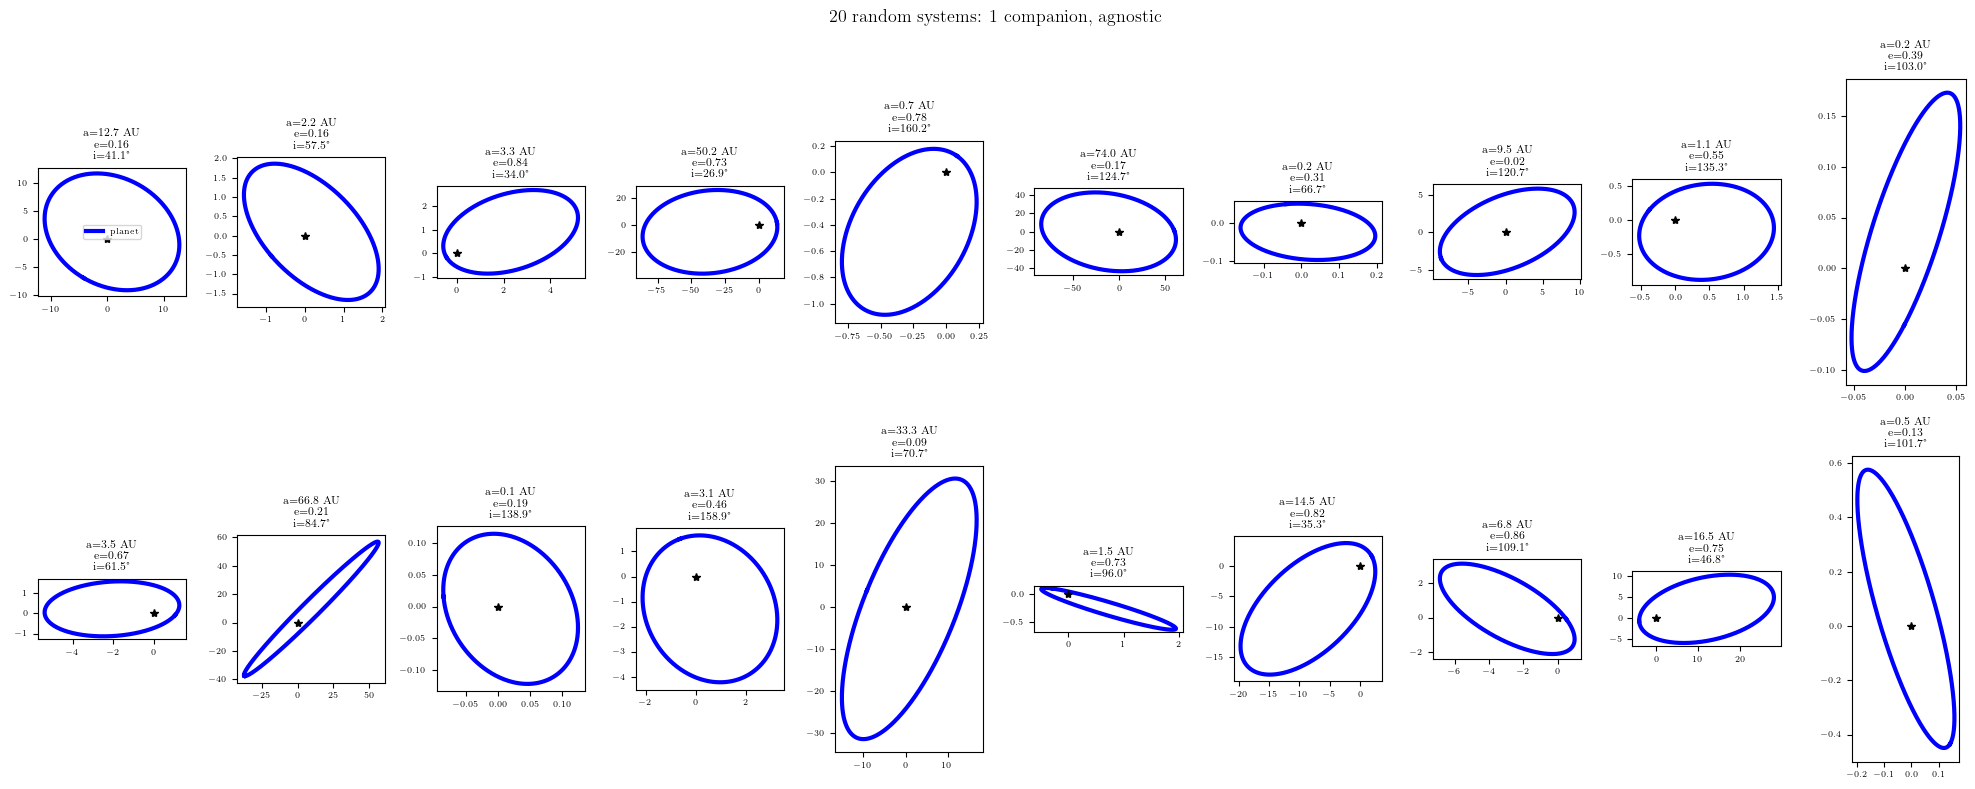

Saved figure: outputs/figures/20systems_1_companion_agnostic.pdf

Generating 1-planet population | filter_snr=True | seed=1981677229
  Dropped 33 stars with missing sig_AL (no noise model)
  processed 500 / 16346 stars
  processed 1000 / 16346 stars
  processed 1500 / 16346 stars
  processed 2000 / 16346 stars
  processed 2500 / 16346 stars
  processed 3000 / 16346 stars
  processed 3500 / 16346 stars
  processed 4000 / 16346 stars
  processed 4500 / 16346 stars
  processed 5000 / 16346 stars
  processed 5500 / 16346 stars
  processed 6000 / 16346 stars
  processed 6500 / 16346 stars
  processed 7000 / 16346 stars
  processed 7500 / 16346 stars
  processed 8000 / 16346 stars
  processed 8500 / 16346 stars
  processed 9000 / 16346 stars
  processed 9500 / 16346 stars
  processed 10000 / 16346 stars
  processed 10500 / 16346 stars
  processed 11000 / 16346 stars
  processed 11500 / 16346 stars
  processed 12000 / 16346 stars
  processed 12500 / 16346 stars
  processed 13000 / 16346 stars

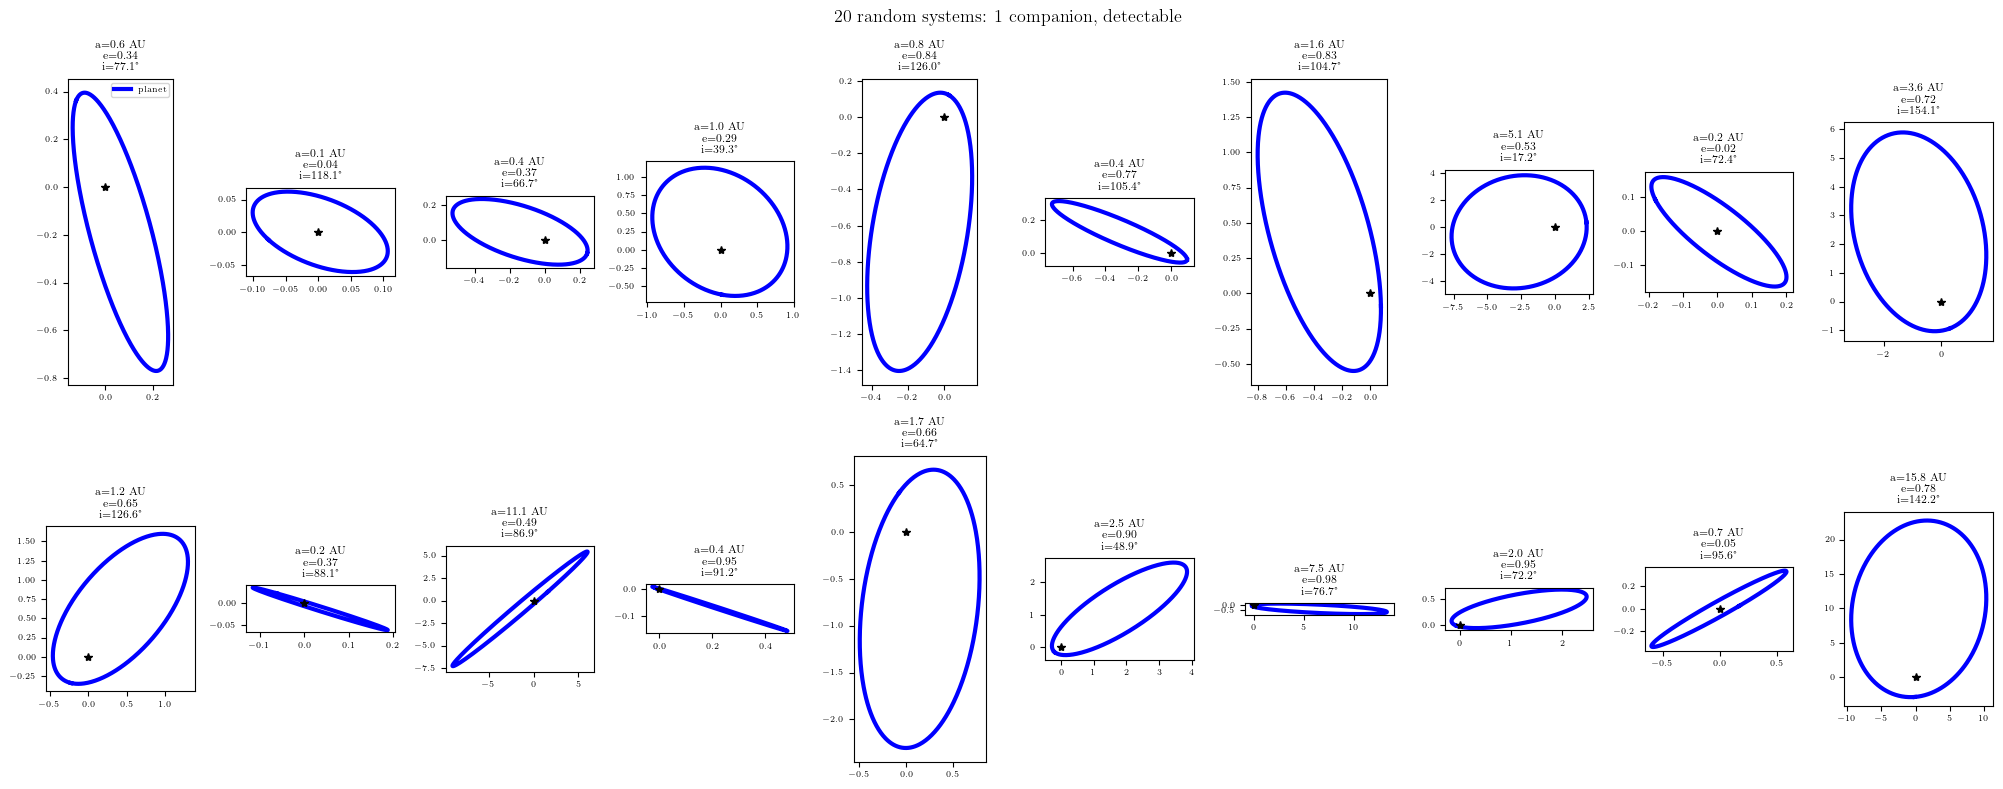

Saved figure: outputs/figures/20systems_1_companion_detectable.pdf

Generating 2-planet population | filter_snr=False | seed=1453894774
  Dropped 33 stars with missing sig_AL (no noise model)
  processed 500 / 16346 stars
  processed 1000 / 16346 stars
  processed 1500 / 16346 stars
  processed 2000 / 16346 stars
  processed 2500 / 16346 stars
  processed 3000 / 16346 stars
  processed 3500 / 16346 stars
  processed 4000 / 16346 stars
  processed 4500 / 16346 stars
  processed 5000 / 16346 stars
  processed 5500 / 16346 stars
  processed 6000 / 16346 stars
  processed 6500 / 16346 stars
  processed 7000 / 16346 stars
  processed 7500 / 16346 stars
  processed 8000 / 16346 stars
  processed 8500 / 16346 stars
  processed 9000 / 16346 stars
  processed 9500 / 16346 stars
  processed 10000 / 16346 stars
  processed 10500 / 16346 stars
  processed 11000 / 16346 stars
  processed 11500 / 16346 stars
  processed 12000 / 16346 stars
  processed 12500 / 16346 stars
  processed 13000 / 16346 st

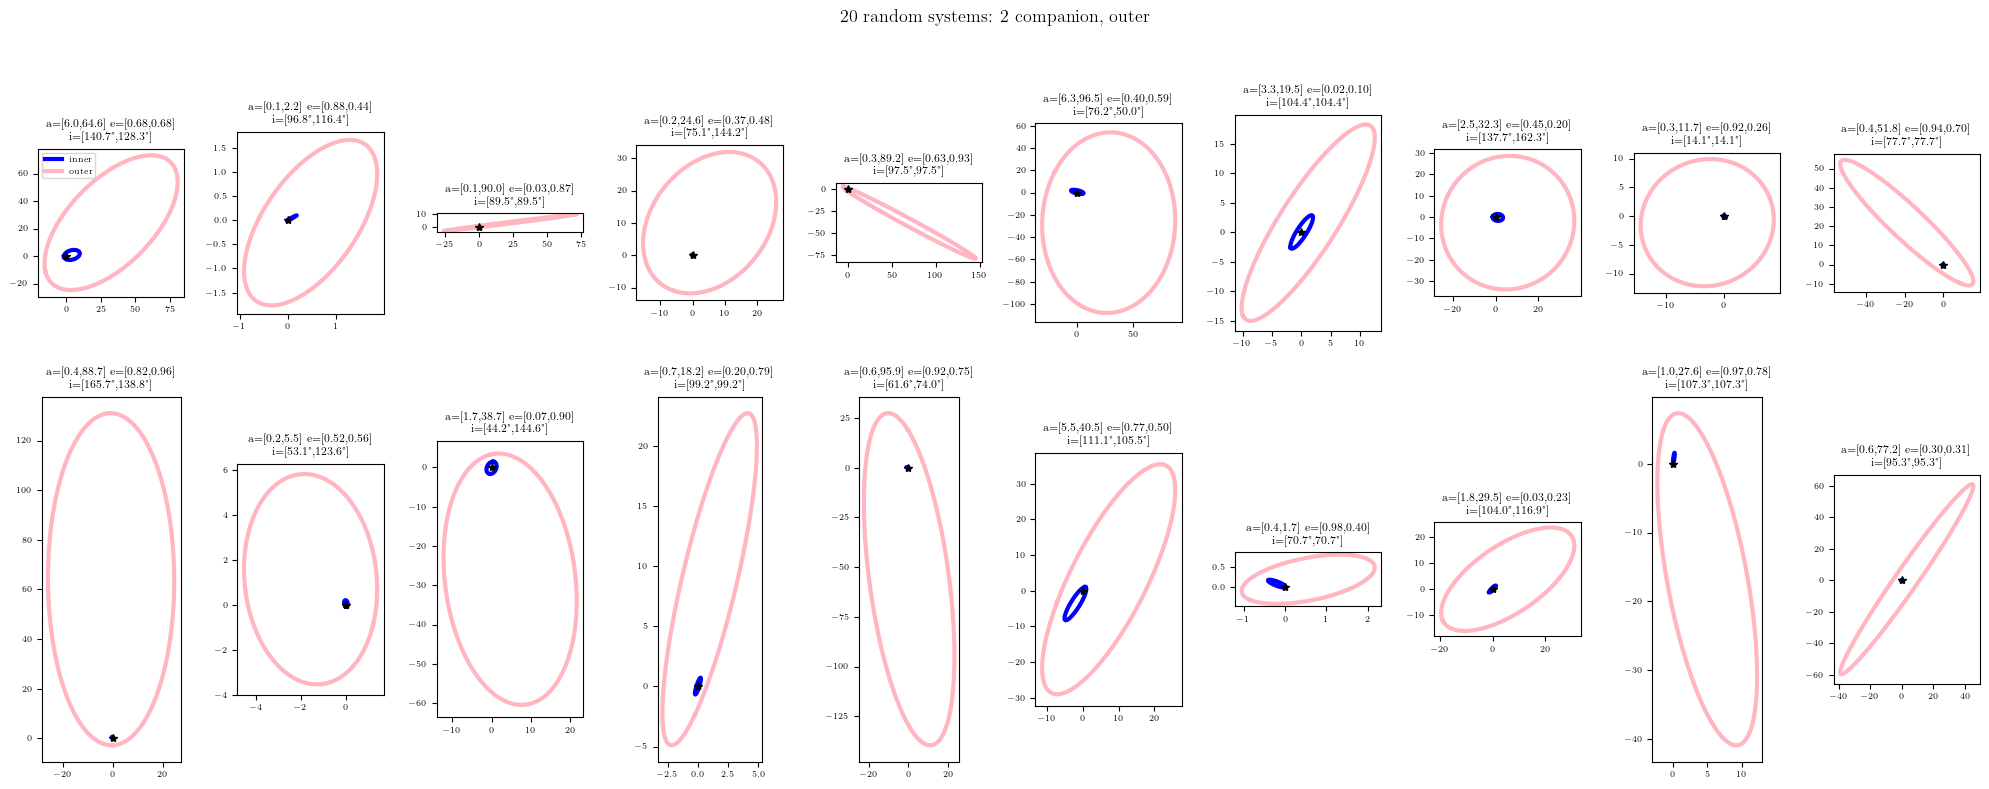

Saved figure: outputs/figures/20systems_2_companion_agnostic.pdf

Generating 2-planet population | filter_snr=True | seed=2368172743
  Dropped 33 stars with missing sig_AL (no noise model)
  processed 500 / 16346 stars
  processed 1000 / 16346 stars
  processed 1500 / 16346 stars
  processed 2000 / 16346 stars
  processed 2500 / 16346 stars
  processed 3000 / 16346 stars
  processed 3500 / 16346 stars
  processed 4000 / 16346 stars
  processed 4500 / 16346 stars
  processed 5000 / 16346 stars
  processed 5500 / 16346 stars
  processed 6000 / 16346 stars
  processed 6500 / 16346 stars
  processed 7000 / 16346 stars
  processed 7500 / 16346 stars
  processed 8000 / 16346 stars
  processed 8500 / 16346 stars
  processed 9000 / 16346 stars
  processed 9500 / 16346 stars
  processed 10000 / 16346 stars
  processed 10500 / 16346 stars
  processed 11000 / 16346 stars
  processed 11500 / 16346 stars
  processed 12000 / 16346 stars
  processed 12500 / 16346 stars
  processed 13000 / 16346 stars

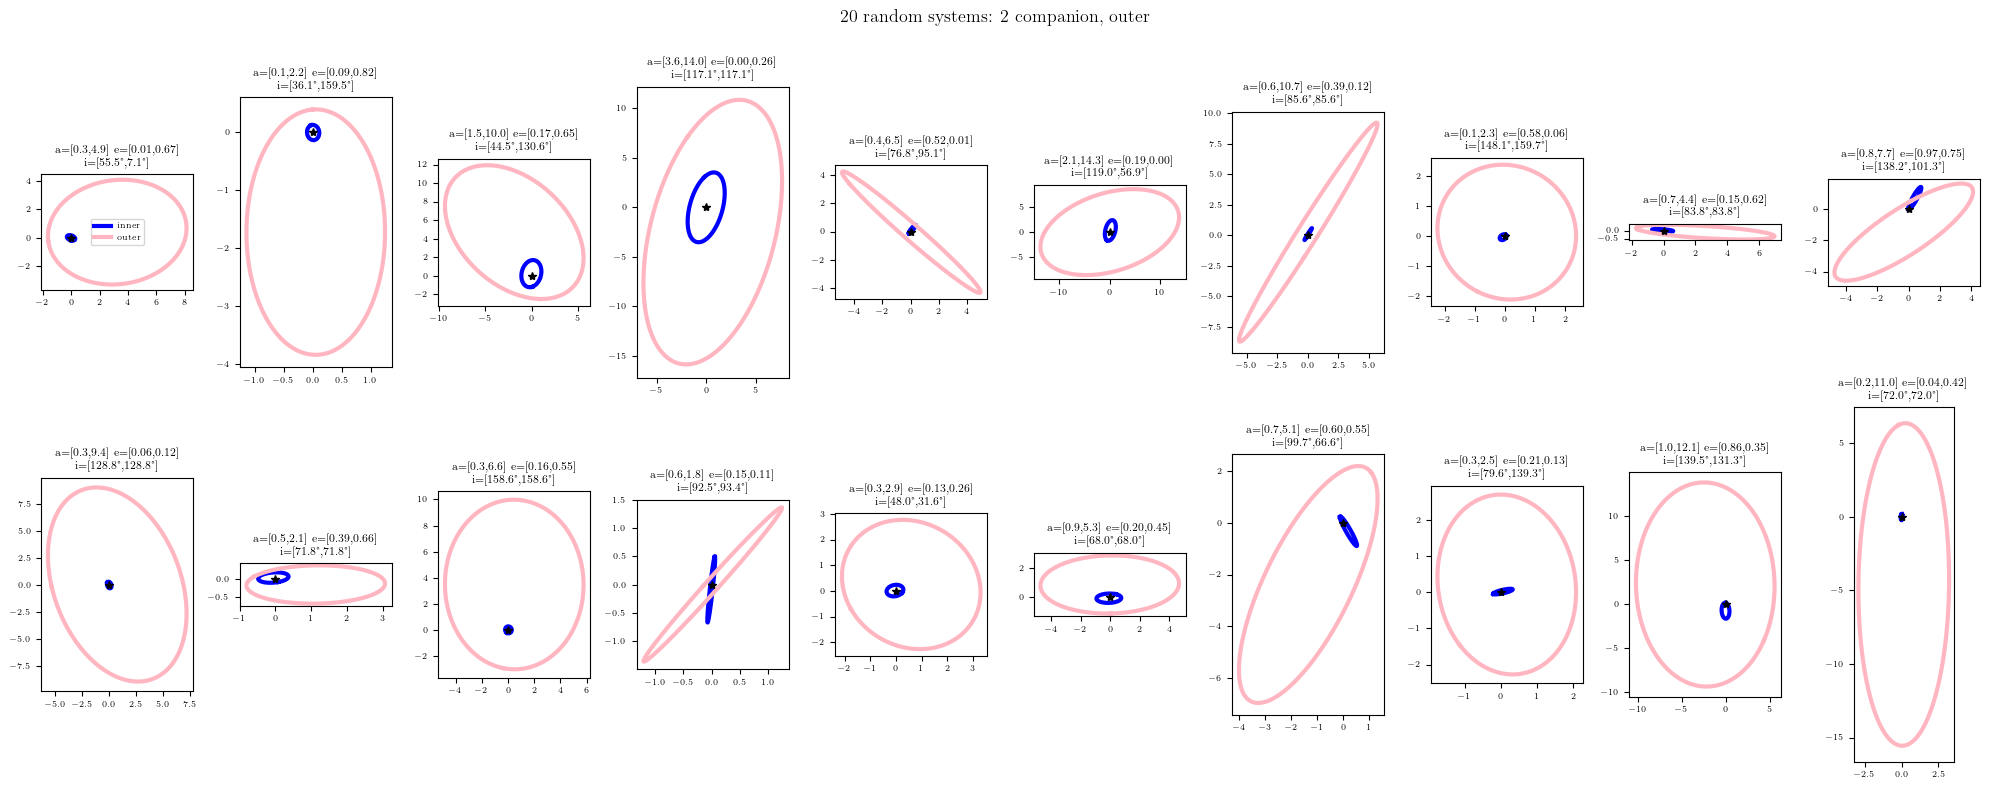

Saved figure: outputs/figures/20systems_2_companion_detectable.pdf


In [6]:
all_pop_dfs = run_all_orbit_populations()

In [7]:
# --------------------------------------------------
# Save population diagnostics plots
# --------------------------------------------------

os.makedirs("outputs/figures/", exist_ok=True)

# 1-planet diagnostics
plot_pop_diagnostics(
    ag_path="outputs/data/1_companion_agnostic.csv",
    snr_path="outputs/data/1_companion_detectable.csv",
    output_path="outputs/figures/pop_diagnostics_1planet.pdf",
    n_planets=1,
)

# 2-planet diagnostics
plot_pop_diagnostics(
    ag_path="outputs/data/2_companion_agnostic.csv",
    snr_path="outputs/data/2_companion_detectable.csv",
    output_path="outputs/figures/pop_diagnostics_2planet.pdf",
    n_planets=2,
)

# random and snr-weighted

Saved to outputs/figures/pop_diagnostics_1planet.pdf
Saved to outputs/figures/pop_diagnostics_2planet.pdf


In [8]:
# --------------------------------------------------
# Gallery of injected companion systems (4 populations x 10 systems)
# --------------------------------------------------
plot_companion_gallery(
    data_dir="outputs/data/",
    output_path="outputs/figures/companion_gallery.pdf",
    n_per_row=10,
    seed=18,
)


Saved to outputs/figures/companion_gallery.pdf


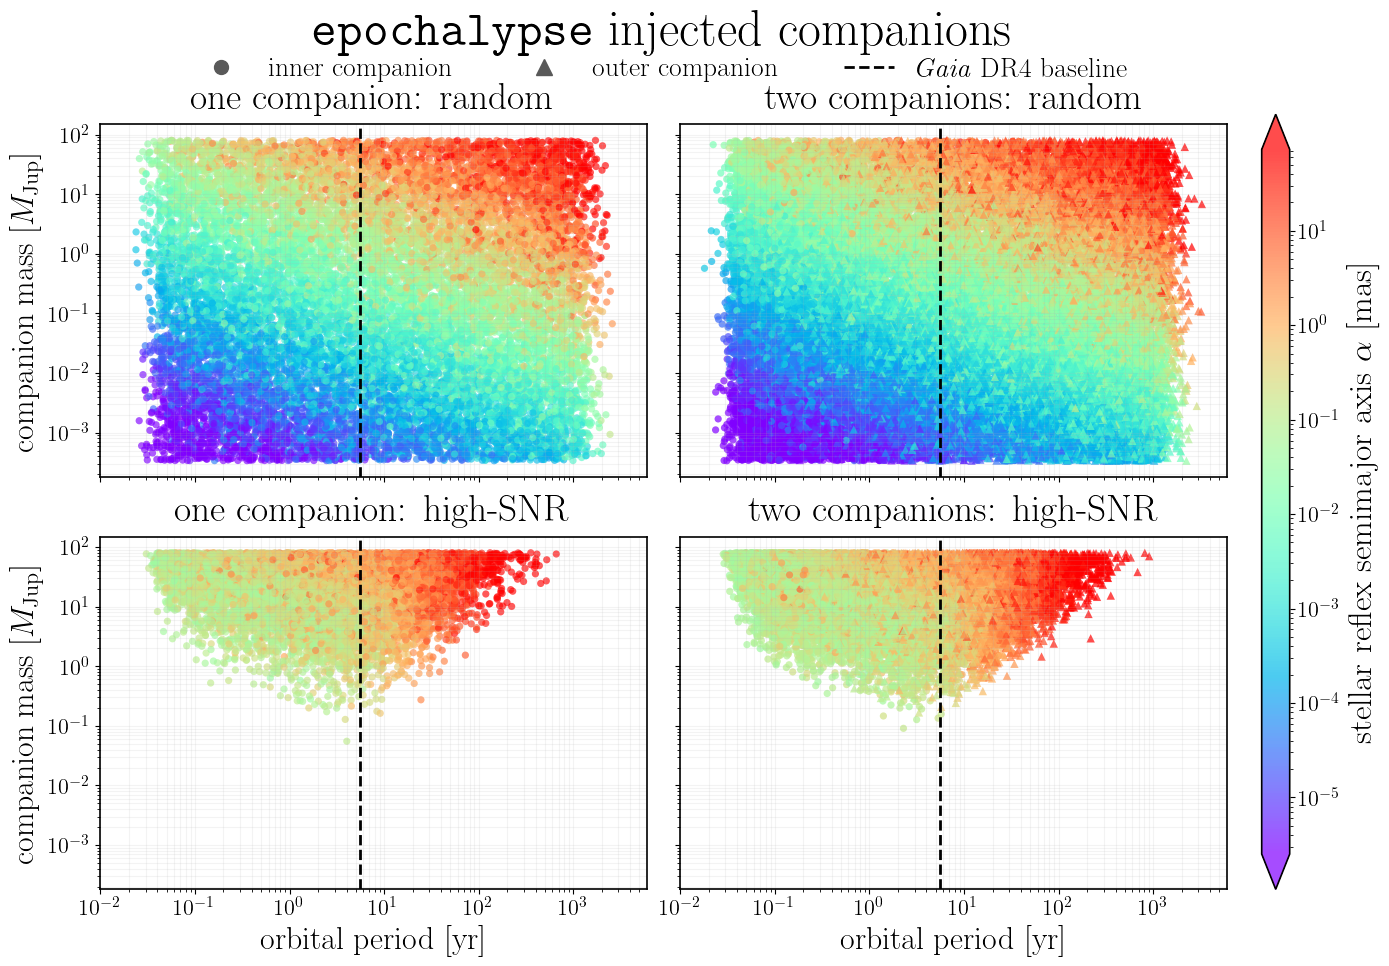

Saved outputs/figures/simulated_planets_mass_period.pdf


In [9]:
from pathlib import Path
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.collections import LineCollection


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """Return a colormap using only the [minval, maxval] slice of `cmap`."""
    cmap = plt.get_cmap(cmap)
    return LinearSegmentedColormap.from_list(
        f"{cmap.name}_trunc", cmap(np.linspace(minval, maxval, n))
    )


def plot_simulated_planet_mass_period(
    data_dir="outputs/data",
    output_path="outputs/figures/simulated_planets_mass_period.pdf",
    observing_baseline_years=5.5,
):
    data_dir = Path(data_dir)
    cmap_trunc = truncate_colormap("rainbow", 0.0, 1.0)
    stars = pd.read_csv(
        data_dir / "stars.csv",
        dtype={"gaia_source_id": str, "source_id_dr2": str},
        usecols=["gaia_source_id", "source_id_dr2", "parallax", "mass_interp"],
    )

    population_specs = [
        ("1_companion_agnostic", 1, "one companion: random"),
        ("2_companion_agnostic", 2, "two companions: random"),
        ("1_companion_detectable", 1, "one companion: high-SNR"),
        ("2_companion_detectable", 2, "two companions: high-SNR"),
    ]

    populations = {}
    all_signatures = []
    for population, n_planets, title in population_specs:
        frame = pd.read_csv(
            data_dir / f"{population}.csv",
            dtype={"gaia_source_id": str, "source_id_dr2": str},
        ).merge(
            stars, on=["gaia_source_id", "source_id_dr2"],
            how="left", validate="one_to_one",
        )

        if n_planets == 1:
            frame["alpha_mas"] = (
                frame["mass_pl"] * M_JUP_IN_MSUN
                / (frame["mass_interp"] + frame["mass_pl"] * M_JUP_IN_MSUN)
                * frame["sma"] * frame["parallax"]
            )
            all_signatures.append(frame["alpha_mas"].to_numpy())
        else:
            for idx in [1, 2]:
                frame[f"alpha_{idx}_mas"] = (
                    frame[f"mass_pl_{idx}"] * M_JUP_IN_MSUN
                    / (frame["mass_interp"] + frame[f"mass_pl_{idx}"] * M_JUP_IN_MSUN)
                    * frame[f"sma_{idx}"] * frame["parallax"]
                )
                all_signatures.append(frame[f"alpha_{idx}_mas"].to_numpy())

        populations[population] = (frame, n_planets, title)

    all_signatures = np.concatenate(all_signatures)
    color_norm = LogNorm(
        vmin=np.quantile(all_signatures, 0.01),
        vmax=np.quantile(all_signatures, 0.99),
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 10), sharex=True, sharey=True,
    )
    # Disable any active layout engine (constrained_layout can be on via the
    # subplots kwarg or rcParams); otherwise newer Matplotlib silently ignores
    # the explicit subplots_adjust below and the panels overlap.
    if hasattr(fig, "set_layout_engine"):
        fig.set_layout_engine("none")
    scatter_for_colorbar = None

    for ax, (population, _, _) in zip(axes.flat, population_specs):
        frame, n_planets, title = populations[population]

        

        if n_planets == 1:
            scatter_for_colorbar = ax.scatter(
                frame["period"], frame["mass_pl"],
                c=frame["alpha_mas"], norm=color_norm, cmap=cmap_trunc,
                s=27, alpha=0.65, linewidths=0, rasterized=True,
            )
        else:
            '''segments = np.stack([
                np.column_stack([frame["period_1"], frame["mass_pl_1"]]),
                np.column_stack([frame["period_2"], frame["mass_pl_2"]]),
            ], axis=1)
            ax.add_collection(LineCollection(
                segments, colors="0.45", linewidths=0.3, alpha=0.08, rasterized=True,
            ))
            '''
            scatter_for_colorbar = ax.scatter(
                frame["period_1"], frame["mass_pl_1"],
                c=frame["alpha_1_mas"], norm=color_norm, cmap=cmap_trunc,
                marker="o", s=27, alpha=0.7, linewidths=0,
                rasterized=True, label="inner companion",
            )
            ax.scatter(
                frame["period_2"], frame["mass_pl_2"],
                c=frame["alpha_2_mas"], norm=color_norm, cmap=cmap_trunc,
                marker="^", s=36, alpha=0.7, linewidths=0,
                rasterized=True, label="outer companion",
            )

        ax.axvline(
            observing_baseline_years, color="k", ls="--", lw=2,
            label=r"\textit{Gaia} DR4 baseline"
        )

        #ax.axhline(13.0, color="0.25", ls=":", lw=2, label=r'13 $M_{\rm Jup}$')
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(title, pad=12, fontsize=27)
        ax.grid(True, which="both", alpha=0.15)
        ax.tick_params(which="both", labelsize=16)

    for ax in axes[-1, :]:
        ax.set_xlabel("orbital period [yr]", fontsize=23)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"companion mass [$M_{\rm Jup}$]", fontsize=23)

    # Explicit layout with the colorbar on the RIGHT. Tick sizes are set
    # locally (above) so this figure is unaffected by rcParams changed elsewhere
    # in the notebook (e.g. the diagnostics figure).
    fig.subplots_adjust(left=0.075, right=0.88, top=0.85, bottom=0.085,
                        hspace=0.17, wspace=0.06)

    cax = fig.add_axes([0.905, 0.085, 0.02, 0.775])
    colorbar = fig.colorbar(
        scatter_for_colorbar, cax=cax, orientation="vertical", extend="both",
    )
    colorbar.set_label(r"stellar reflex semimajor axis $\alpha$ [mas]", fontsize=24)
    colorbar.ax.tick_params(labelsize=16)

    # centre the suptitle + legend over the panel block (not the whole figure,
    # since the colorbar occupies the right margin)
    _cx = 0.5 * (0.075 + 0.88)
    fig.suptitle(r"\texttt{epochalypse} injected companions", fontsize=36, x=_cx, y=0.965)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", color="0.35", lw=0, markersize=10,
               label="inner companion"),
        Line2D([0], [0], marker="^", color="0.35", lw=0, markersize=11,
               label="outer companion"),
        Line2D([0], [0], color="k", ls="--", lw=2,
               label=r"\textit{Gaia} DR4 baseline"),
    ]
    fig.legend(handles=legend_handles, loc="center", bbox_to_anchor=(_cx, 0.905),
               ncol=3, frameon=False, fontsize=20, columnspacing=2.4,
               handlelength=1.8)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path)
    fig.savefig(output_path.with_suffix(".png"), dpi=200)
    plt.show()
    print(f"Saved {output_path}")
    return fig, axes


planet_population_figure, planet_population_axes = plot_simulated_planet_mass_period()